# Exercise 2 for the class EE-568 Theory and Methods of Reinforcement Learning taught at EPFL in Spring 2026 by Prof. Volkan Cevher

### Names and Sciper numbers

#### Group Member 1:
Name: Kevin Abou Jaoude

Sciper number: 358300

#### Group Member 2:
Name: Fuad Khuri

Sciper number: 357574

#### Group Member 3:
Name: Youssef Dib

Sciper number: 339964

### LLM Usage

You are encouraged **not to use** LLMs or other AI tools so that you can fully engage with and learn the course material. Uploading the full document or copy-pasting the questions into an AI tool are strictly not allowed. 

If you do use them at any point, please clearly and transparently disclose what tool was used, and how in the next cell. 

If AI use is suspected but not clearly explained, we reserve the right to ask follow-up questions to clarify your understanding of the work. 

# Linear Programming exercise

In [1]:
### Do the imports -- no need to change this
import numpy as np
import matplotlib.pyplot as plt
import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'
import sys
sys.path.insert(0, "src/")
from environment import GridWorldEnvironment
from MDPsolver import MDPsolver
from utils import *
from plot import *
%load_ext autoreload
%autoreload 2

***Before starting, we recall the use of the gridworld environment.***

The gridworld environment is instantiated via the class `GridWorldEnvironment`. 

***It takes 4 input values:***
- `reward_mode` : Integer between 0 and 3 for different reward profiles,
- `size`: Gridworld size,
- `prop`: Probability assigned to the event that the agent does not follow the chosen action but another one selected uniformely at random,
- `gamma`: Discount factor of the environment.

***Interface of a Gridworld instance:***
- `print(gridworld.n_states)` # return the number of states
- `print(gridworld.n_actions)` # return the number of actions
- `print(gridworld.r)` # return a matrix where each element indicates the reward corresponding to each (state, action) pair.
- `print(gridworld.gamma)` # return the discount factor
- `print(gridworld.sparseT[action])` # Input: action, Return: a matrix containing the state-to-state transition probabilities for the action passed as input.

<img src="../dynamic_programming/src/vis_gridworld.png" alt="fishy" class="bg-primary" width="400px">

In [2]:
reward_mode = 2 # see below to visualize the reward function
size = 3 # size of the gridworld (3x3)
prop = 0.1 # proportion of randomly taken steps due to noise in the environment 
gamma=0.99 # discount factor

gridworld = GridWorldEnvironment(reward_mode, size, prop=0, gamma=gamma)
print('Reward function: \n', gridworld.r) # visualize the reward function

Reward function: 
 [[   0.    0.    0.    0.]
 [  -1.   -1.   -1.   -1.]
 [  -1.   -1.   -1.   -1.]
 [  -1.   -1.   -1.   -1.]
 [-100. -100. -100. -100.]
 [  -1.   -1.   -1.   -1.]
 [  -1.   -1.   -1.   -1.]
 [  -1.   -1.   -1.   -1.]
 [  -1.   -1.   -1.   -1.]]


We will use a solver to compute the **optimal value function** to measure the suboptimality of the policies produced by our algorithms.

To access the optimal value function use `solver.v`.

In [3]:
solver = MDPsolver(gridworld) # call the MDPsolver class
solver.value_iteration() # call the value iteration method to find V^* once

## Ex 1: Solving the Primal [20 points]

We will leverage the powerful `scipy` library to solve **Linear Programs (LPs)**. Below we give an example of using the [linprog module](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.linprog.html) to solve a simple LP:

\begin{aligned}
 & \min_{x := \begin{bmatrix}
x_0  \\
x_1
\end{bmatrix}  \in \mathbb{R}^2}  \begin{bmatrix}
-1  \\
4
\end{bmatrix} ^\top x
\\&  \text{s.t.}  \begin{bmatrix}
-3 & 1 \\
1 & 2 
\end{bmatrix} \mathbb{x} \le  \begin{bmatrix}
6  \\
4 
\end{bmatrix} , \quad  x_1\ge -3 \,.
\end{aligned}

The **code example below will be instructive** when you later construct the LP corresponding to the MDP.

In [4]:
from scipy.optimize import linprog # import the linear programming solver from scipy

# Note that the bounds argument in linprog is a  sequence of (min, max) pairs for each element in x, defining the minimum and maximum values.
x0_bounds = (None, None)
x1_bounds = (-3, None)

# call linear programming solver:
res = linprog([-1, 4], 
              A_ub=[[-3, 1], [1, 2]], 
              b_ub=[6, 4], 
              bounds=[x0_bounds, x1_bounds],
              method="simplex")
print('The solution is ', res.x) # access and print the solution
print(res.message) # print the message of the solver (e.g., terminated successfully)

The solution is  [10. -3.]
Optimization terminated successfully.


/var/folders/v6/gl4pd99j4gd_z41b14ydy5640000gn/T/ipykernel_93610/2674117054.py:8: DeprecationWarning: `method='simplex'` is deprecated and will be removed in SciPy 1.11.0. Please use one of the HiGHS solvers (e.g. `method='highs'`) in new code.
  res = linprog([-1, 4],


Now we are ready to use `linprog` to solve the LP problem in gridworld.

We define a distribution `mu` over the states.

In [5]:
mu = np.ones((gridworld.n_states,1))/gridworld.n_states # initialize mu

Next, we need to **instantiate the constraints of the primal problem**. Notice that `scipy` requires the inequality constraints in the form $A_{ub} x \leq b_{ub}$.


To this end, we rewrite the constraint $EV \geq \gamma P V + r$ in the form expected by `scipy`.

In [6]:
def build_matrix(env):
    E = np.kron(np.eye(env.n_states), np.ones(env.n_actions)).T # build the matrix E
    P = env.T.transpose((1,0,2)).reshape(env.n_states*env.n_actions, -1) # build the matrix P
    return env.gamma*P - E

(Side remark: The indexing in the matrices `E` and `P` here is slightly different from the one in the lecture. This does not change any of the formulas from the slides since both matrices are indexed in the same way, consistently throughout this exercise. You may ignore this comment.)

Then, use the function `linprog` of `scipy` to solve the dual problem and show that you can retrieve the same $V^\star$ computed with the solver and stored in `solver.v`

In [7]:
# Call linear programming solver with the correct inputs:
primal_out = linprog((1 - gridworld.gamma)*mu, 
                     A_ub= build_matrix(gridworld), 
                     b_ub= -gridworld.r.flatten(),
                     method="simplex",
                     bounds=[(None,0)])

/var/folders/v6/gl4pd99j4gd_z41b14ydy5640000gn/T/ipykernel_93610/3351187514.py:2: DeprecationWarning: `method='simplex'` is deprecated and will be removed in SciPy 1.11.0. Please use one of the HiGHS solvers (e.g. `method='highs'`) in new code.
  primal_out = linprog((1 - gridworld.gamma)*mu,


(*Hint:* Check slide 23 for the matrix form (or slide 8), lecture 3 to recall the primal.)

We can access the solution of the primal LP using `primal_out.x`. Compare the error with the value of `solver.v`.

In [8]:
np.linalg.norm(primal_out.x - solver.v) # plot 2-norm

np.float64(4.111484296790486e-14)

***Question***

By running the following two cells, plot (in matrix form) `mu` and the difference between `solver.v` and `primal_out.x`. Then, answer the following question: Can we ensure that `np.linalg.norm(primal_out.x - solver.v)` is zero (up to numerical errors) for the current value of `mu`?  

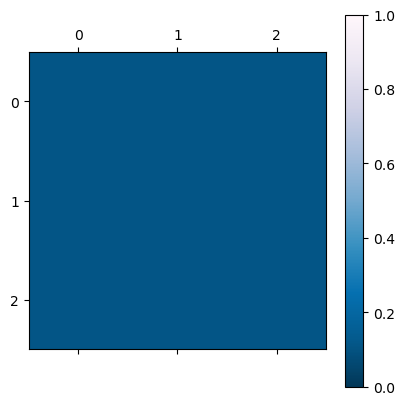

In [9]:
plt.matshow(mu.reshape(size, size), cmap='PuBu_r', vmin=0,vmax=1) # plot distribution mu over states 
plt.colorbar()

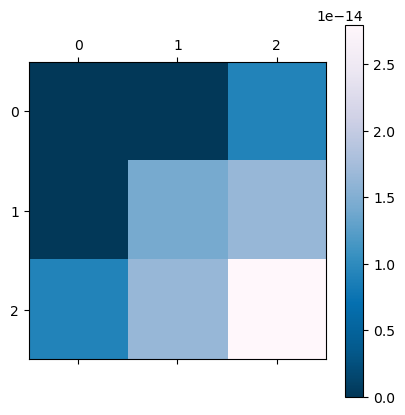

In [10]:
plt.matshow((solver.v - primal_out.x).reshape(size, size), cmap='PuBu_r') # plot the difference between the value function and the solution of the linear program
plt.colorbar()

**Answer**

Yes, we can expect the difference between `primal_out.x` and `solver.v` to be effectively zero, up to numerical errors, for the current value of $\mu$.

Both methods solve for the same optimal value function $V^*$. Since $\mu$ is uniform and all its entries are strictly positive, the LP objective $(1 - \gamma)\langle \mu, V \rangle$ penalizes overestimation in every state equally, meaning the optimal solution must be tight (i.e., equal to $V^*$) at every state. Therefore, the two solutions coincide up to numerical precision.

Next, we repeat the same experiment with a different value of `mu`. 

Note that we do **not** overwrite `mu` or `primal_out` (but instead have `mu2` and `primal_out2`, since for all other exercises, we will use the original, uniform `mu`.)

In [11]:
# overwrite mu with a new distribution:
mu2 = np.zeros((gridworld.n_states,1))
mu2[-3] = 1

Fill in the following, as before but for the distribution `mu2`.

In [12]:
# solve the LP with the new mu2:
primal_out2 = linprog((1-gridworld.gamma)*mu2, 
                      A_ub= build_matrix(gridworld), 
                      b_ub= -gridworld.r.flatten(),
                      method="simplex",
                      bounds=[(None,0)])

/var/folders/v6/gl4pd99j4gd_z41b14ydy5640000gn/T/ipykernel_93610/2336818665.py:2: DeprecationWarning: `method='simplex'` is deprecated and will be removed in SciPy 1.11.0. Please use one of the HiGHS solvers (e.g. `method='highs'`) in new code.
  primal_out2 = linprog((1-gridworld.gamma)*mu2,


We compare with the value computed by Value Iteration `solver.v`.

In [13]:
np.linalg.norm(primal_out2.x - solver.v) # plot 2-norm

np.float64(2.772246430099758)

Note that now, the optimal solution of the primal LP `primal_out2.x` and the optimal value function `solver.v` do not coincide anymore! 

This is despite the fact that the optimal value function `solver.v` was computed **right in the beginning**, before we even initialized the `mu` for solving the LP the first time. So `solver.v` is definitely the correct optimal value function for each state.

**Question:**

Why does it make sense that the two values do not coincide?

**Answer:**

The LP with $\mu_2$ concentrated on a single state optimizes the expected return starting only from that state. Its objective is to minimize $V$ at the state where $\mu_2 = 1$, so it does not need to tighten the values at other states. In contrast, `solver.v` is computed via value iteration, which gives the optimal value for every state, independent of $\mu$. Since the LP focuses only on one state's outcome while value iteration optimizes globally, their solutions can differ at states not weighted by $\mu_2$.

***Question***

We plot again in matrix form `mu2`, `solver.v` and `primal_out2.x`. Then answer the following: What can happen in the states where `mu2 = 0`?

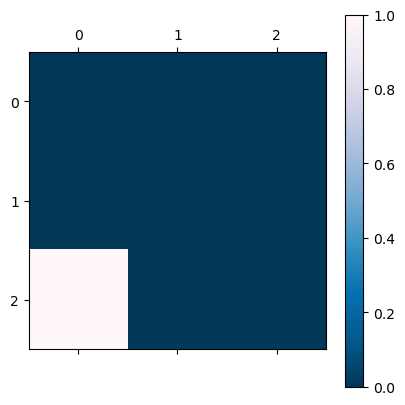

In [14]:
plt.matshow(mu2.reshape(size, size), cmap='PuBu_r', vmin=0,vmax=1) # plot distribution mu over states
plt.colorbar()

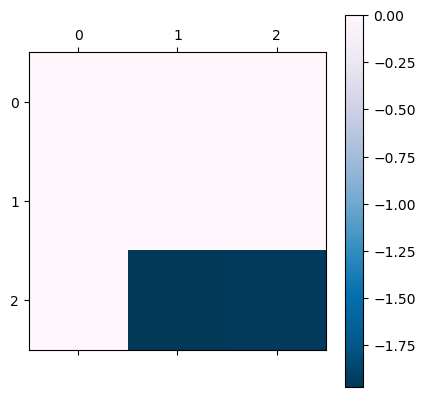

In [15]:
plt.matshow((solver.v - primal_out2.x).reshape(size, size), cmap='PuBu_r') # plot the difference between the value function and the solution of the linear program
plt.colorbar()

**Answer:**

In states where $\mu_2 = 0$, the LP has no incentive to optimize the value — it only needs to satisfy the Bellman constraints $EV \geq r + \gamma PV$. Since these states do not appear in the objective, the LP is free to assign them any values that satisfy the constraints, even if those values are far from optimal. The LP only focuses on minimizing the value at the state where $\mu_2 = 1$, and effectively ignores the rest. Thus, in states with $\mu_2 = 0$, the LP solution may be a loose upper bound on $V^*$ rather than matching it exactly.

# Ex 2: Solving the Dual [20 points]

Try now to solve the dual using again the `linprog` routine of scipy. 

Note that we did **not** overwrite `mu` (i.e. it is still uniform, and `primal_out.x` is the primal solution for this `mu`).

(*Hint:* Check slide 23 for the matrix form (or slide 11), lecture 3 to recall the dual.)

In [16]:
# solve the dual LP with the correct inputs:
dual_out = linprog(-gridworld.r.flatten(), 
              A_eq= build_matrix(gridworld).T, 
              b_eq= -(1 - gridworld.gamma)*mu,
              method="simplex",
              bounds=(0,None))

/var/folders/v6/gl4pd99j4gd_z41b14ydy5640000gn/T/ipykernel_93610/414874128.py:2: DeprecationWarning: `method='simplex'` is deprecated and will be removed in SciPy 1.11.0. Please use one of the HiGHS solvers (e.g. `method='highs'`) in new code.
  dual_out = linprog(-gridworld.r.flatten(),


We verify that **strong duality** holds:

In [17]:
dual_value = dual_out.x.dot(gridworld.r.reshape(gridworld.n_states*gridworld.n_actions)) # compute the optimal value of the dual
primal_value = (1 - gridworld.gamma)*primal_out.x.dot(mu)[0] # compute the optimal value of the primal
abs(primal_value - dual_value) # print the absolute difference between the primal and dual optimum

np.float64(8.326672684688674e-17)

Note that the solution of the dual problem gives us the **optimal occupancy measure**. Given this:

1. Obtain the **greedy policy** given the solution of the primal problem.

2. **Evaluate** this policy and **compare** the obtained values with the solution of the dual problem.

In [18]:
def evaluate_policy(pi, env, tol=1e-10):
    """Implementation of policy evaluation through iteratively applying using a certain policy 
    Args:
        pi: a policy
        env: environment
        tol: a scalar to dermerminate whether the policy evaluation convergences
    Returns:
        v: an array with the values of the actions chosen
        q: an array with the q values    
    """
    v = np.zeros(env.n_states)
    q = np.zeros((env.n_states, env.n_actions))
    while True:
        v_old = np.copy(v)
        for a in range(env.n_actions):
            q[:, a] = env.r[:, a] + env.gamma * env.sparseT[a].dot(v)
        for s in range(env.n_states):
            action_taken = pi[s]
            v[s] = q[s,action_taken]
        if np.linalg.norm(v - v_old) < tol:
            break
    return v, q

In [19]:
pi = dual_out.x.reshape(gridworld.n_states,gridworld.n_actions).argmax(axis=1) # side remark/explanation: We know a deterministic optimal policy exists. It turns out that we can find it by checking for which component a lambda_opt(s,a) is > 0, and then setting pi_opt(a|s) = 1 for that action.
v,q = evaluate_policy(pi,gridworld) # evaluate the policy
print(np.linalg.norm(v-primal_out.x)) # print the 2-norm between the value function and the solution of the primal LP

4.111484296790486e-14


***Questions***

Derive the dual from the primal. That is, show that it indeed the dual linear program of the primal program (and that thus the values coincide by strong duality).

(*Hint:* You may consult the supplementary material of lecture 3, slide 9 and 10 in the appendix to read about strong duality in LPs. Make sure to explain step by step why it works.)

***Answer:***

We start with the primal LP:

**Primal (P):**
$$\min_{V \in \mathbb{R}^{|\mathcal{S}|}} (1 - \gamma)\langle \mu, V \rangle \quad \text{s.t.} \quad EV \ge r + \gamma PV$$

Rewriting the constraint: $(E - \gamma P)V \ge r$. Let $A = E - \gamma P$ and $b = r$.

Using the standard LP duality rule: for a primal of form $\min_x c^T x$ s.t. $Ax \ge b$, the dual is $\max_y b^T y$ s.t. $A^T y = c$, $y \ge 0$.

We identify: $x = V$, $c = (1 - \gamma)\mu$, $A = E - \gamma P$, $b = r$.

**Dual (D):**
$$\max_{\lambda \ge 0} \langle r, \lambda \rangle \quad \text{s.t.} \quad (E - \gamma P)^T \lambda = (1 - \gamma)\mu$$

Which is equivalent to:
$$\max_{\lambda \ge 0} \langle \lambda, r \rangle \quad \text{s.t.} \quad E^T \lambda - \gamma P^T \lambda = (1 - \gamma)\mu$$

This is exactly the dual LP from the lecture (Slide 11/23). Since both the primal and dual are feasible and bounded, strong duality holds by the LP strong duality theorem, meaning the optimal primal and dual objective values coincide.

# Ex 3: Implement REPS with known dynamics [20 points]

In this exercize you will **implement the REPS algorithm** as we have seen in the lectures.
Namely, recall the following **details of the algorithm**:

1. **Initialization** (uniform): $\forall s, a, \lambda_0(s,a) = \frac{1}{|\mathcal{S}||\mathcal{A}|}$;

2. **REPS loss computation**: $\mathcal{L}(\lambda, V) = (1-\gamma) \langle \mu, V \rangle + \frac{1}{\eta}\log{\langle \lambda, \exp{(\eta(r+\gamma P V - E V))} \rangle}$;

3. **Solving for the values**: $V_{k}=\text{argmin}_{V}~{\mathcal{L}(\lambda_k, V)}$, for this we will use the `minimize` function from `scipy.optimize`;

4. **Updating the occupancy measure:** $\lambda_{k+1} \propto \lambda_k \cdot \exp{(\eta (r+\gamma P V_{k} - E V_{k}))}$ (unnormalized, you then must make sure it sums to 1 in every step).

In [20]:
from scipy.optimize import minimize
from scipy.special import logsumexp, softmax
from plot import plot_log_lines, plot_lines

In [21]:
def reps_loss(lambda_, V, eta, initial):
    delta = gridworld.r.reshape(gridworld.n_states * gridworld.n_actions) + build_matrix(gridworld).dot(V)
    loss = (1 - gridworld.gamma) * initial.flatten().dot(V) + (1 / eta) * logsumexp(np.log(lambda_) + eta * delta)
    return loss

def minimize_reps_loss(lambda_, eta, initial):
    loss = lambda V : reps_loss(lambda_, V, eta, initial)
    V = minimize(loss, np.zeros(gridworld.n_states), method = "CG", options={'maxiter': 1000})
    return V.x

In [22]:
K = 40 # number of iterations
mu = np.ones((gridworld.n_states,1))/gridworld.n_states # initialize mu again to the uniform distribution (not needed, just to be safe)

#initialize the variables
subopts = []
feasibility_errors = []
lambda_ = np.ones(gridworld.n_states*gridworld.n_actions)/gridworld.n_states/gridworld.n_actions
iterates = [lambda_]
subopts.append(-lambda_.T.dot(gridworld.r.reshape(gridworld.n_states*gridworld.n_actions))+(1-gridworld.gamma)*mu.T.dot(solver.v)[0])
feasibility_error = np.linalg.norm(build_matrix(gridworld).T.dot(lambda_) + (1-gridworld.gamma)*mu)
feasibility_errors.append(feasibility_error)

# REPS: iterate over K steps
for k in range(K):
    eta = 1/np.sqrt(k+1) # set the step size
    
    V = minimize_reps_loss(lambda_, eta, mu) # minimize the reps loss
    delta = gridworld.r.reshape(gridworld.n_states*gridworld.n_actions) + build_matrix(gridworld).dot(V) # compute the advantage function
    
    new_lambda_ = lambda_ * np.exp(eta * delta) # update the lambda
    new_lambda_ /= np.sum(new_lambda_) # normalize the lambda_
    lambda_ = new_lambda_
    
    # store the suboptimality and feasibility errors:
    subopt = -lambda_.T.dot(gridworld.r.reshape(gridworld.n_states*gridworld.n_actions))+(1-gridworld.gamma)*mu.T.dot(solver.v)[0]
    feasibility_error = np.linalg.norm(build_matrix(gridworld).T.dot(lambda_) + (1-gridworld.gamma)*mu)
    subopts.append(subopt)
    feasibility_errors.append(feasibility_error)
    iterates.append(lambda_)

**Plot of the suboptimality of iterates produced by REPS**

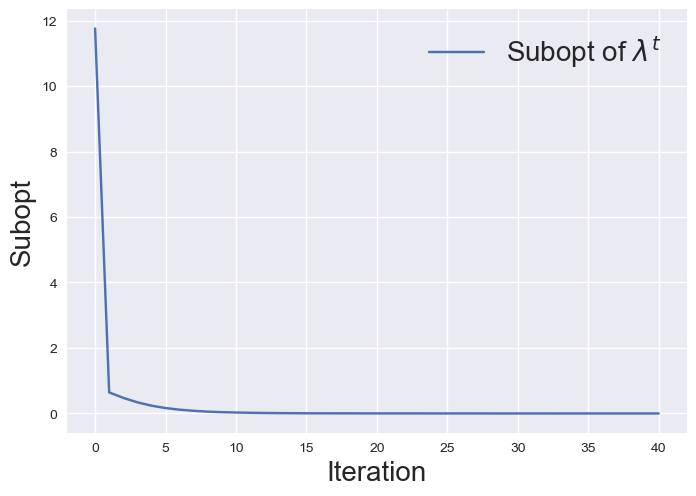

In [23]:
plot_lines([np.array(subopts)], [r"Subopt of $\lambda^t$"], ["Iteration", "Subopt"], "figs", "subopts.pdf", show = True)

**Theoretical Derivation of REPS**

Prove that the iterates of REPS are equivalent to the iterates produced by the following updates:

$$ \lambda_{k+1} = \mathrm{argmax}_{\lambda} \left( \langle \lambda, r \rangle - \frac{1}{\eta} \left\langle \lambda,~ \log\left(\frac{\lambda}{\lambda_k}\right) \right\rangle \right) \quad \text{s.t.} \quad E^T \lambda = \gamma P^T \lambda + (1 - \gamma) \mu. $$

(*Hint:* Check the slides of lecture if you do not know where to start.)

**Answer:**

We want to show that the REPS update

$$\lambda_{k+1} \propto \lambda_k \cdot \exp\!\big(\eta(r + \gamma PV_k - EV_k)\big), \quad V_k = \arg\min_V \mathcal{L}(\lambda_k, V)$$

is equivalent to solving:

$$\lambda_{k+1} = \arg\max_{\lambda \geq 0} \left\{ \langle \lambda, r \rangle - \frac{1}{\eta}\left\langle \lambda, \log\frac{\lambda}{\lambda_k}\right\rangle \right\} \quad \text{s.t.} \quad E^T\lambda = \gamma P^T\lambda + (1-\gamma)\mu.$$

**Proof.** We form the Lagrangian of the constrained problem, introducing a dual variable $V \in \mathbb{R}^{|\mathcal{S}|}$ for the equality constraint:

$$L(\lambda, V) = \langle \lambda, r \rangle - \frac{1}{\eta}\langle \lambda, \log(\lambda / \lambda_k) \rangle + \langle V,\; (1-\gamma)\mu + \gamma P^T\lambda - E^T\lambda \rangle.$$

Rearranging:

$$L(\lambda, V) = \langle \lambda,\; r + (\gamma P - E)V \rangle - \frac{1}{\eta}\langle \lambda, \log(\lambda/\lambda_k)\rangle + (1-\gamma)\langle \mu, V\rangle.$$

We maximize over $\lambda \geq 0$. Taking the derivative with respect to $\lambda_i$ and setting it to zero:

$$r_i + [(\gamma P - E)V]_i - \frac{1}{\eta}\big(\log(\lambda_i / \lambda_{k,i}) + 1\big) = 0.$$

Solving for $\lambda_i$:

$$\lambda_i = \lambda_{k,i} \cdot \exp\!\big(\eta\,(r_i + (\gamma P - E)V_i) - 1\big) \propto \lambda_{k,i} \cdot \exp\!\big(\eta\,(r + \gamma PV - EV)_i\big).$$

This is exactly the REPS multiplicative update (before normalization). Substituting this optimal $\lambda$ back into the Lagrangian, we obtain (up to additive constants) the dual function:

$$g(V) = (1-\gamma)\langle \mu, V \rangle + \frac{1}{\eta}\log\langle \lambda_k, \exp(\eta(r + \gamma PV - EV))\rangle$$

which is the REPS loss $\mathcal{L}(\lambda_k, V)$. The dual variable $V_k$ is found by minimizing this expression, which is exactly step 3 of the algorithm. $\blacksquare$

**Plot the constraints violation**

Plot the value of $||(E^T - \gamma P^T)\lambda - (1 - \gamma) \mu || $, varying the parameter `maxiter` of the `scipy.minimize` function.

(To be clear: in the code above, modify this line ```minimize(loss, np.zeros(gridworld.n_states), method = "CG", options={'maxiter': 1000})``` and plot for varying `maxiter`.)

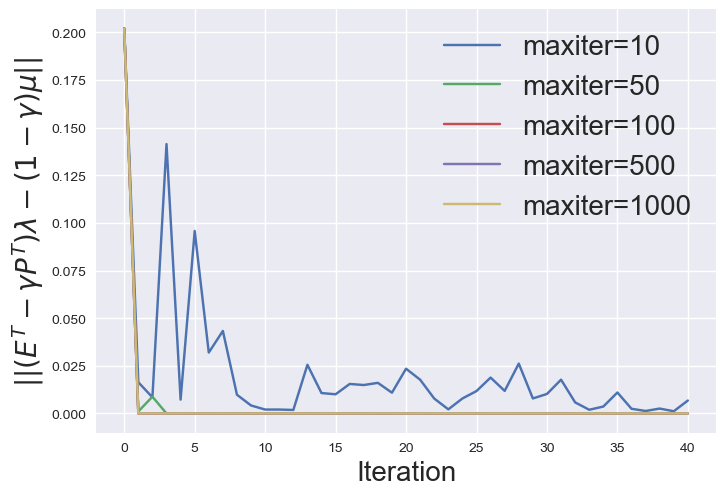

In [24]:
# Experiment with varying maxiter values
maxiter_values = [10, 50, 100, 500, 1000]
all_feasibility_errors = []

for maxiter_val in maxiter_values:
    lambda_exp = np.ones(gridworld.n_states * gridworld.n_actions) / gridworld.n_states / gridworld.n_actions
    feas_errors = []
    feas_errors.append(np.linalg.norm(build_matrix(gridworld).T.dot(lambda_exp) + (1 - gridworld.gamma) * mu))
    
    for k in range(K):
        eta = 1 / np.sqrt(k + 1)
        loss = lambda V: reps_loss(lambda_exp, V, eta, mu)
        V_exp = minimize(loss, np.zeros(gridworld.n_states), method="CG", options={'maxiter': maxiter_val}).x
        delta_exp = gridworld.r.reshape(gridworld.n_states * gridworld.n_actions) + build_matrix(gridworld).dot(V_exp)
        lambda_exp = lambda_exp * np.exp(eta * delta_exp)
        lambda_exp /= np.sum(lambda_exp)
        feas_errors.append(np.linalg.norm(build_matrix(gridworld).T.dot(lambda_exp) + (1 - gridworld.gamma) * mu))
    
    all_feasibility_errors.append(np.array(feas_errors))

plot_lines(all_feasibility_errors, 
           [f"maxiter={m}" for m in maxiter_values], 
           ["Iteration", "$|| (E^T - \\gamma P^T)\\lambda - (1 - \\gamma) \\mu ||$"], 
           "figs", "constraints_maxiter.pdf", show=True)

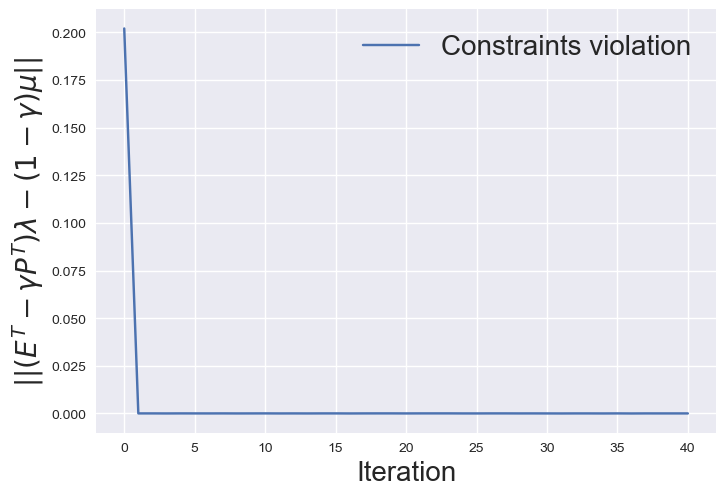

In [25]:
plot_lines([np.array(feasibility_errors)], [r"Constraints violation"], ["Iteration", "$|| (E^T - \gamma P^T)\lambda - (1 - \gamma) \mu ||$"], "figs", "constraints.pdf", show = True)

**Question**

Empirically, is the value of $||(E^T - \gamma P^T)\lambda - (1 - \gamma) \mu || $ higher for high or low values of `maxiter`?

Explain why this is the case.

**Answer:**

The constraint violation is **lower for higher values of `maxiter`** and higher for low values.

The variable $V$ in the REPS loss is the Lagrange dual variable associated with the Bellman flow constraint $E^T\lambda = \gamma P^T\lambda + (1-\gamma)\mu$ (as shown in the derivation above). When `maxiter` is large, the minimization over $V$ is more accurate, meaning $V$ is closer to the true dual optimum. A well-optimized $V$ better enforces the constraint through the Lagrangian mechanism. Conversely, when `maxiter` is small, the optimizer terminates early, $V$ is far from optimal, and the constraint is poorly enforced, resulting in larger violation.

**Question:**

Strictly speaking, are the actual iterates $\lambda_k$ in the implementation above valid occupancy measures? In other words, is $E^T \lambda_k = \gamma P^T \lambda_k + (1 - \gamma) \mu$ strictly satisfied for all iterates? Explain why this is (not) the case.

**Answer:**

No, the iterates $\lambda_k$ are **not** strictly valid occupancy measures. The Bellman flow constraint $E^T\lambda_k = \gamma P^T\lambda_k + (1-\gamma)\mu$ is not explicitly enforced at any step. In the REPS algorithm, this constraint is handled implicitly through the Lagrangian dual variable $V$: the minimization of $\mathcal{L}(\lambda_k, V)$ over $V$ only approximately enforces the constraint (depending on how well the inner optimization converges, i.e., the value of `maxiter`). The only hard constraint imposed on $\lambda_k$ is normalization ($\sum \lambda_k = 1$), which is necessary but not sufficient for $\lambda_k$ to be a valid occupancy measure.

**Plot of the suboptimality of the policies extracted from the $\lambda^k$'s**

*Extract the policies from the $\lambda^k$-iterates:* $$\pi_{\lambda^k}(a |s) = \frac{\lambda_k(s,a)} {\sum_{a\in\mathcal{A}}\lambda_k(s,a)}.$$

In [26]:
def extract_policies_from_occ_measures(occ_measures):
    policies = []
    for occ_measure in occ_measures:
        policy = np.zeros((gridworld.n_states, gridworld.n_actions)) # initialize the policy
        occ_measure = occ_measure.reshape(gridworld.n_states, -1) # reshape the occupancy measure
        states_occ_measure = occ_measure.sum(axis=1) # compute the occupancy measure over states (not state-action pairs)
        for s in range(gridworld.n_states):
            policy[s] = occ_measure[s] / states_occ_measure[s] # compute the policy
        policies.append(policy)
        
    return policies

In [27]:
policies = extract_policies_from_occ_measures(iterates)

*Extract the occupancy measures from the policies:* $$ \lambda_{\pi_{\lambda^k}}(s,a) = (1 - \gamma)\sum^{\infty}_{t=0} \gamma^t \mathbb{P}[s_t=s,a_t=a | s_0 \sim \mu, \pi_{\lambda^k}].$$

In [28]:
def extract_occ_measures_from_policies(policies): # extract the occupancy measures from the policies (we do not require you to follow this)
    occ_measures = []
    for policy in policies:
        v = - (1 - gridworld.gamma)*(mu.repeat(gridworld.n_actions,axis=1)*policy).reshape(gridworld.n_states*gridworld.n_actions)
        matrix = np.eye(gridworld.n_states*gridworld.n_actions)
        T_pi = np.expand_dims(gridworld.T.transpose((1,0,2)),axis=3).repeat(gridworld.n_actions, axis=3)
        pi_tensor = np.expand_dims(policy, axis=(0,1)).repeat(T_pi.shape[0], axis=0).repeat(T_pi.shape[1], axis=1)
        T_pi = T_pi*pi_tensor
        matrix = gridworld.gamma*T_pi.reshape(gridworld.n_states*gridworld.n_actions,gridworld.n_states*gridworld.n_actions)- matrix
        occ_measure = np.linalg.solve(matrix.T, v)
        occ_measures.append(occ_measure)
    return occ_measures

In [29]:
occ_measures = extract_occ_measures_from_policies(policies)

*Check whether $\lambda_{\pi_{\lambda_k}} = \lambda_k$*:

In [30]:
# compute the difference between the occupancy measures and the iterates
diff_occ_measures = [np.linalg.norm(occ_measure - iterate) for occ_measure, iterate in zip(occ_measures, iterates)] 

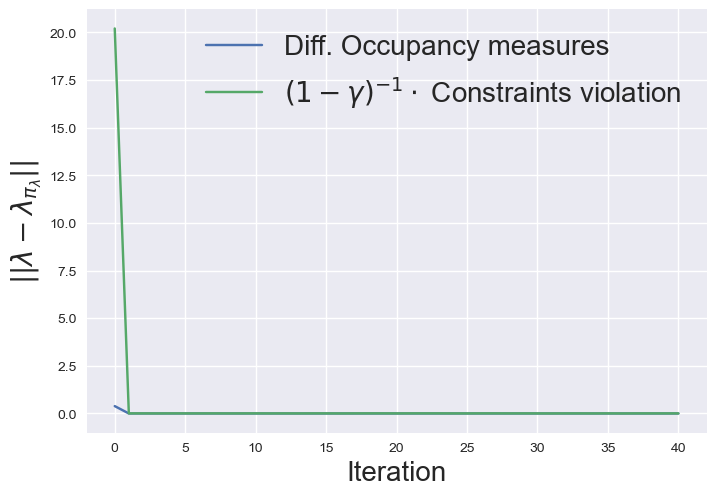

In [31]:
# plot the difference between the occupancy measures and the iterates
plot_lines([np.array(diff_occ_measures), np.array(feasibility_errors)/(1 - gridworld.gamma)], [r"Diff. Occupancy measures", r"$(1-\gamma)^{-1}\cdot$ Constraints violation"], ["Iteration", "$|| \lambda - \lambda_{\pi_\lambda}||$"], "figs", "diff_occ_measures.pdf", show = True)

**Questions**

- How does the norm of the difference $|| \lambda^k - \lambda_{\pi_{\lambda^k}}||$ relate to the constraint violation $|| (E^T - \gamma P^T)\lambda^k - (1 - \gamma) \mu ||$ ?

- If $|| (E^T - \gamma P^T)\lambda^k - (1 - \gamma) \mu ||$ is small, can you conclude that $|| \lambda^k - \lambda_{\pi_{\lambda^k}}||$ is also small ? 

*Hint: For both, you can answer leveraging the result in Lemma 3 of https://arxiv.org/pdf/2112.14004.pdf*

- As a consequence how is $|| \lambda^k - \lambda_{\pi_{\lambda^k}}||$ affected by the value of `maxiter`?

*Hint:* Recall your empirical finding about the impact of `maxiter` (above).

***Answer:***

- By Lemma 3 of [Mutti et al., 2022](https://arxiv.org/pdf/2112.14004.pdf), we have:

$$\|\lambda^k - \lambda_{\pi_{\lambda^k}}\|_1 \leq \frac{1}{1-\gamma}\|(E^T - \gamma P^T)\lambda^k - (1-\gamma)\mu\|_1.$$

So the difference between $\lambda^k$ and the true occupancy measure of its induced policy is bounded (up to the factor $\frac{1}{1-\gamma}$) by the constraint violation. The plot confirms this: the scaled constraint violation curve $\frac{1}{1-\gamma}\|(E^T - \gamma P^T)\lambda^k - (1-\gamma)\mu\|$ tracks above $\|\lambda^k - \lambda_{\pi_{\lambda^k}}\|$, acting as an upper bound.

- Yes. If $\|(E^T - \gamma P^T)\lambda^k - (1-\gamma)\mu\|$ is small, then by Lemma 3, $\|\lambda^k - \lambda_{\pi_{\lambda^k}}\|$ is also small (up to the $\frac{1}{1-\gamma}$ factor).

- Since higher `maxiter` leads to lower constraint violation (as we observed above), and the constraint violation upper bounds $\|\lambda^k - \lambda_{\pi_{\lambda^k}}\|$, higher `maxiter` also leads to smaller $\|\lambda^k - \lambda_{\pi_{\lambda^k}}\|$. Conversely, low `maxiter` yields large constraint violation and thus large discrepancy between $\lambda^k$ and $\lambda_{\pi_{\lambda^k}}$.

**Evaluate the extracted policies**

In this section, we compute the value functions of the extracted policies which is $V^{\pi_{\lambda^k}}$

In [32]:
def evaluate_policy_sequence(policies, env, tol=1e-10):
    values = []
    for pi in policies:
        v = np.zeros(env.n_states) # initialize value function
        q = np.zeros((env.n_states, env.n_actions)) #initialize Q-value
        while True:
            v_old = np.copy(v) # save a copy of value function for the convergence criterion at the step
            for a in range(env.n_actions):
                q[:, a] = env.r[:, a] + env.gamma * env.sparseT[a].dot(v) #calculate Q-value
            for s in range(env.n_states):
                v[s] = pi[s].dot(q[s]) #calculate value function by $v(s) = max_a Q(s,a)$
            if np.linalg.norm(v - v_old) < tol: # convergence criterion
                break
        values.append(v)
    return values

In [33]:
def check_correctness(policies):
    values = evaluate_policy_sequence(policies, gridworld) # evaluate the policies
    for policy,v in zip(policies,values):
        state_occ_measure = solver.mu_policy(policy, stochastic=True) # compute the state occupancy measure
        occ_measure = np.expand_dims(state_occ_measure, axis=1).repeat(gridworld.n_actions, axis=1)*policy
        primal = occ_measure.reshape(gridworld.n_states*gridworld.n_actions).dot(gridworld.r.reshape(gridworld.n_states*gridworld.n_actions)) # compute the primal value
        dual = (1 - gridworld.gamma)*mu.T.dot(v) # compute the dual value
        assert primal - dual < 1e-7
    return [ (1 - gridworld.gamma)*mu.T.dot(v) for v in values] # return the values

**Question**

Do you expect $(1 - \gamma)\langle \mu, V^{\pi_{\lambda^k}} \rangle$ to be (approximately) equal to or (very) different from $\langle \lambda^k, r \rangle $? Does the answer depend on the value of `maxiter`?

*Hint: Recall that $(1 - \gamma)\langle \mu, V^{\pi_{\lambda^k}} \rangle = \langle \lambda_{\pi_{\lambda^k}}, r \rangle $ and argue using your previous answer concerning the term $|| \lambda^k - \lambda_{\pi_{\lambda^k}}||$.*

**Answer:**

We know that $(1-\gamma)\langle \mu, V^{\pi_{\lambda^k}}\rangle = \langle \lambda_{\pi_{\lambda^k}}, r\rangle$ by the LP duality relationship between a policy's value and its occupancy measure. Therefore:

$$\big|\langle \lambda^k, r\rangle - (1-\gamma)\langle \mu, V^{\pi_{\lambda^k}}\rangle\big| = \big|\langle \lambda^k - \lambda_{\pi_{\lambda^k}},\; r\rangle\big| \leq \|r\|_\infty \cdot \|\lambda^k - \lambda_{\pi_{\lambda^k}}\|_1.$$

From our previous analysis, $\|\lambda^k - \lambda_{\pi_{\lambda^k}}\|_1$ is controlled by the constraint violation via Lemma 3. So:

- When `maxiter` is **high**, the constraint violation is small, $\|\lambda^k - \lambda_{\pi_{\lambda^k}}\|$ is small, and the two quantities are approximately equal.
- When `maxiter` is **low**, the constraint violation is large, $\|\lambda^k - \lambda_{\pi_{\lambda^k}}\|$ can be large, and the two quantities can differ significantly.

So yes, the answer depends on `maxiter`.

In [34]:
policy_values = check_correctness(policies) # check that $(1 - \gamma)\langle \mu, V^{\pi} \rangle = \langle \lambda_{\pi}, r \rangle $ for all policies.
policy_subopts = (1 - gridworld.gamma)*mu.T.dot(solver.v) - policy_values # compute the suboptimality of the policies

**Plot the suboptimalities**

Plot $(1 - \gamma)\langle \mu, V^{\pi^\star}\rangle - (1 - \gamma)\langle \mu, V^{\pi_{\lambda^k}} \rangle$.

Plot $(1 - \gamma)\langle \mu, V^{\pi^\star}\rangle - \langle \lambda^k, r \rangle$.

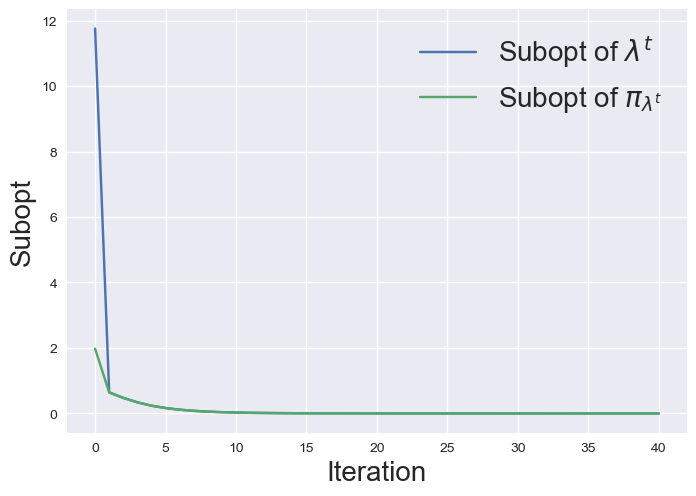

In [35]:
plot_lines([np.array(subopts), policy_subopts.flatten()], [r"Subopt of $\lambda^t$", r"Subopt of $\pi_{\lambda^t}$"], ["Iteration", "Subopt"], "figs", "subopts.pdf", show = True)

## Ex 4: Lagrangian methods [ 20 points ]

In this section we compute an optimal policy finding a saddle point of the Lagrangian $\mathcal{L}(\lambda, V)$, defined as follows

$$
\mathcal{L}(\lambda, V) = \langle \lambda, r \rangle + \langle (1 - \gamma) \mu + \gamma P^T \lambda - E^T \lambda, V \rangle .
$$

Finding a saddle point of the Lagrangian means solving the following problem:

$$ 
\mathrm{argmax}_{\lambda \geq 0} \min_{V \in \mathbb{R}^{|\mathcal{S}|}} \mathcal{L}(\lambda, V).
$$

By slide 6 in Lecture 3 it should be clear that there exists a saddle point pair $\lambda^\star, V^\star$ such that $|| V^\star ||_{\infty} \leq \frac{\max_{s,a} |r(s,a)|}{1 - \gamma}$. Therefore, we can consider looking for a saddle point over a restricted domain $\mathcal{V} = \{ V : ||V||_{\infty} \leq \frac{\max_{s,a} |r(s,a)|}{1 - \gamma} \}$:

$$ 
\mathrm{argmax}_{\lambda \geq 0} \min_{V \in \mathcal{V}} \mathcal{L}(\lambda, V).
$$

At this point we solve this problem with gradient descent ascent updates 

$$
\lambda^{k+1} \propto \lambda^k \odot \exp(\eta_{\lambda} \nabla_{\lambda} \mathcal{L}(\lambda^k, V^k)),
$$

$$
V^{k+1} = \Pi_{\mathcal{V}}[V^k - \eta_V \nabla_{V} \mathcal{L}(\lambda^k, V^k)].
$$

**Question**: 

Compute the following gradients:

$$  \nabla_{\lambda} \mathcal{L}(\lambda^k, V^k) = r + \gamma P^T V^k - E^T V^k $$

$$ \nabla_{V} \mathcal{L}(\lambda^k, V^k) = (1 - \gamma) \mu + \gamma P^T \lambda^k - E^T \lambda^k $$

**Question:**

Which of the following conditions ensure that the policy $$\pi_{\lambda^k}(a |s) = \frac{\lambda_k(s,a)} {\sum_{a\in\mathcal{A}}\lambda^k(s,a)}$$ is $\epsilon$-suboptimal ?

(a) $$\langle \lambda^\star, r \rangle - \langle \lambda^k, r \rangle \leq \epsilon.$$
(b) $$(1 - \gamma)\langle \mu, V^\star \rangle - \langle \mu, V^k \rangle \leq \epsilon.$$
(c) $$ \mathcal{L}(\lambda^\star, V^k) - \mathcal{L}(\lambda^k, V^{\pi^{\lambda^k}}) \leq \epsilon.$$

Answer (a),(b) or (c).

**Answer**

We can answer this by elimination:

**(a) is not sufficient.**

Condition (a) says the dual objective gap is small: $\langle \lambda^\star, r \rangle - \langle \lambda^k, r \rangle \leq \epsilon$. However, $\langle \lambda^k, r \rangle$ equals the performance of $\pi_{\lambda^k}$ only when $\lambda^k$ is exactly feasible (satisfies the Bellman flow constraints). In general:
$$\langle \lambda^k, r \rangle \neq (1-\gamma)\langle \mu, V^{\pi_{\lambda^k}} \rangle,$$
so a small gap in the dual objective says nothing directly about the policy performance $(1-\gamma)\langle \mu, V^\star - V^{\pi_{\lambda^k}} \rangle$.

**(b) is not sufficient.**

The definition of $\epsilon$-suboptimality requires $(1-\gamma)\langle \mu, V^\star - V^{\pi_{\lambda^k}} \rangle \leq \epsilon$. Condition (b) reads $(1-\gamma)\langle \mu, V^\star \rangle - \langle \mu, V^k \rangle \leq \epsilon$, which is missing the $(1-\gamma)$ factor on the second term. More importantly, $V^k$ is a primal LP iterate, not the true value function $V^{\pi_{\lambda^k}}$ of the induced policy. A small primal objective gap does not guarantee that the extracted policy is near-optimal.

**(c) is sufficient.**

The saddle-point gap collapses to exactly the right quantity:
- Since $\lambda^\star$ satisfies the Bellman flow constraints, its Lagrangian penalty vanishes: $\mathcal{L}(\lambda^\star, V^k) = \langle \lambda^\star, r \rangle = (1-\gamma)\langle \mu, V^\star \rangle$.
- Since the expected advantage of any policy under its own value function is zero: $\mathcal{L}(\lambda^k, V^{\pi_{\lambda^k}}) = (1-\gamma)\langle \mu, V^{\pi_{\lambda^k}} \rangle$.

So condition (c) becomes exactly:
$$(1-\gamma)\langle \mu, V^\star \rangle - (1-\gamma)\langle \mu, V^{\pi_{\lambda^k}} \rangle \leq \epsilon,$$
which is the definition of $\epsilon$-suboptimality. The answer is **(c)**.

### * Question [20 points]

Prove that the answer you gave at the question above implies that the policy $$\pi_{\lambda_k}(a |s) = \frac{\lambda_k(s,a)} {\sum_{a\in\mathcal{A}}\lambda^k(s,a)}$$ is $\epsilon$-suboptimal.
*Recall:* A policy $\pi$ is $\epsilon$-suboptimal if $ (1 - \gamma)  \langle\mu , V^\star - V^{\pi} \rangle\leq \epsilon$

 **Answer**

We show that condition (c) directly implies $(1-\gamma)\langle \mu, V^\star - V^{\pi_{\lambda^k}} \rangle \leq \epsilon$.

Since $\lambda^\star$ is an optimal (and hence valid) occupancy measure, it satisfies the Bellman flow constraint:
$$(E^T - \gamma P^T)\lambda^\star = (1-\gamma)\mu \implies (1-\gamma)\mu + \gamma P^T\lambda^\star - E^T\lambda^\star = 0.$$

Therefore:
$$\mathcal{L}(\lambda^\star, V^k) = \langle \lambda^\star, r \rangle + \langle 0, V^k \rangle = \langle \lambda^\star, r \rangle = (1-\gamma)\langle \mu, V^\star \rangle,$$
where the last equality is LP duality between primal and dual optimal solutions.

Expanding the Lagrangian:
$$\mathcal{L}(\lambda^k, V^{\pi_{\lambda^k}}) = \langle \lambda^k, r \rangle + \langle (1-\gamma)\mu + \gamma P^T\lambda^k - E^T\lambda^k,\; V^{\pi_{\lambda^k}} \rangle.$$

Rearranging (adding and subtracting $(1-\gamma)\langle \mu, V^{\pi_{\lambda^k}} \rangle$):
$$= (1-\gamma)\langle \mu, V^{\pi_{\lambda^k}} \rangle + \sum_{s,a} \lambda^k(s,a)\Bigl[r(s,a) + \gamma \sum_{s'} P(s'|s,a)V^{\pi_{\lambda^k}}(s') - V^{\pi_{\lambda^k}}(s)\Bigr].$$

The bracketed expression is the advantage function $A^{\pi_{\lambda^k}}(s,a) = Q^{\pi_{\lambda^k}}(s,a) - V^{\pi_{\lambda^k}}(s)$. Since
$\pi_{\lambda^k}(a|s) = \lambda^k(s,a) / \sum_{a'}\lambda^k(s,a')$, we have $\lambda^k(s,a) = c(s)\,\pi_{\lambda^k}(a|s)$ where $c(s) = \sum_a \lambda^k(s,a)$. Therefore:
$$\sum_{s,a} \lambda^k(s,a)\,A^{\pi_{\lambda^k}}(s,a) = \sum_s c(s) \underbrace{\sum_a \pi_{\lambda^k}(a|s)\,A^{\pi_{\lambda^k}}(s,a)}_{=\,0} = 0,$$
since the expected advantage under any policy is always zero. Hence:
$$\mathcal{L}(\lambda^k, V^{\pi_{\lambda^k}}) = (1-\gamma)\langle \mu, V^{\pi_{\lambda^k}} \rangle.$$

Substituting Steps 1 and 2 into condition (c):
$$(1-\gamma)\langle \mu, V^\star \rangle - (1-\gamma)\langle \mu, V^{\pi_{\lambda^k}} \rangle \leq \epsilon,$$
i.e., $(1-\gamma)\langle \mu, V^\star - V^{\pi_{\lambda^k}} \rangle \leq \epsilon$, which is exactly the definition of $\pi_{\lambda^k}$ being $\epsilon$-suboptimal.